In [4]:
import sys

sys.path.append("../../")

import importlib, NB_config

importlib.reload(NB_config)
from NB_config import *

In [5]:
df = pd.read_csv(DATASET_PATH, low_memory=False)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 149,485 rows × 60 columns


,name,city,country,country_name,continent,latitude,longitude,stars,review_count,description,...,country_grouped_JP,country_grouped_KR,country_grouped_MY,country_grouped_NL,country_grouped_PT,country_grouped_TH,country_grouped_TW,country_grouped_US,country_grouped_ZA,country_grouped_other
0,Trèsind Studio,Dubai,AE,United Arab Emirates,Asia,-0.110637,0.423128,2.930484,198,NaN,...,False,False,False,False,False,False,False,False,False,True
1,Atrevo,Porto,PT,Portugal,Europe,0.503516,-0.490516,2.953156,76,NaN,...,False,False,False,False,True,False,False,False,False,False
2,Chocho,Paris,FR,France,Europe,0.799604,-0.333556,3.129031,82,NaN,...,False,False,False,False,False,False,False,False,False,False


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149485 entries, 0 to 149484
Data columns (total 60 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   name                    149485 non-null  str    
 1   city                    149485 non-null  str    
 2   country                 149485 non-null  str    
 3   country_name            149485 non-null  str    
 4   continent               149485 non-null  str    
 5   latitude                143835 non-null  float64
 6   longitude               143835 non-null  float64
 7   stars                   149485 non-null  float64
 8   review_count            149485 non-null  int64  
 9   description             119405 non-null  str    
 10  popularity              149485 non-null  float64
 11  attr_wheelchair         149485 non-null  int64  
 12  attr_fee                149485 non-null  int64  
 13  attr_internet_access    149485 non-null  int64  
 14  attr_smoking            149485 

In [7]:
missing = (
    df.isnull()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
description_clean,30080,20.12
description,30080,20.12
categories_clean,10910,7.30
latitude,5650,3.78
longitude,5650,3.78


In [ ]:
dummy_cols = [col for col in df.columns if col.startswith('entity_type_')]
df['entity_type'] = df[dummy_cols].idxmax(axis=1).str.replace('entity_type_', '')
df.loc[df[dummy_cols].sum(axis=1) == 0, 'entity_type'] = 'attraction'
print(df['entity_type'].value_counts())

In [15]:
source_cols = [col for col in df.columns if col.startswith('source_')]

df['source'] = df[source_cols].idxmax(axis=1).str.replace('source_', '')

df.loc[df[source_cols].sum(axis=1) == 0, 'source'] = 'TripAdvisor'

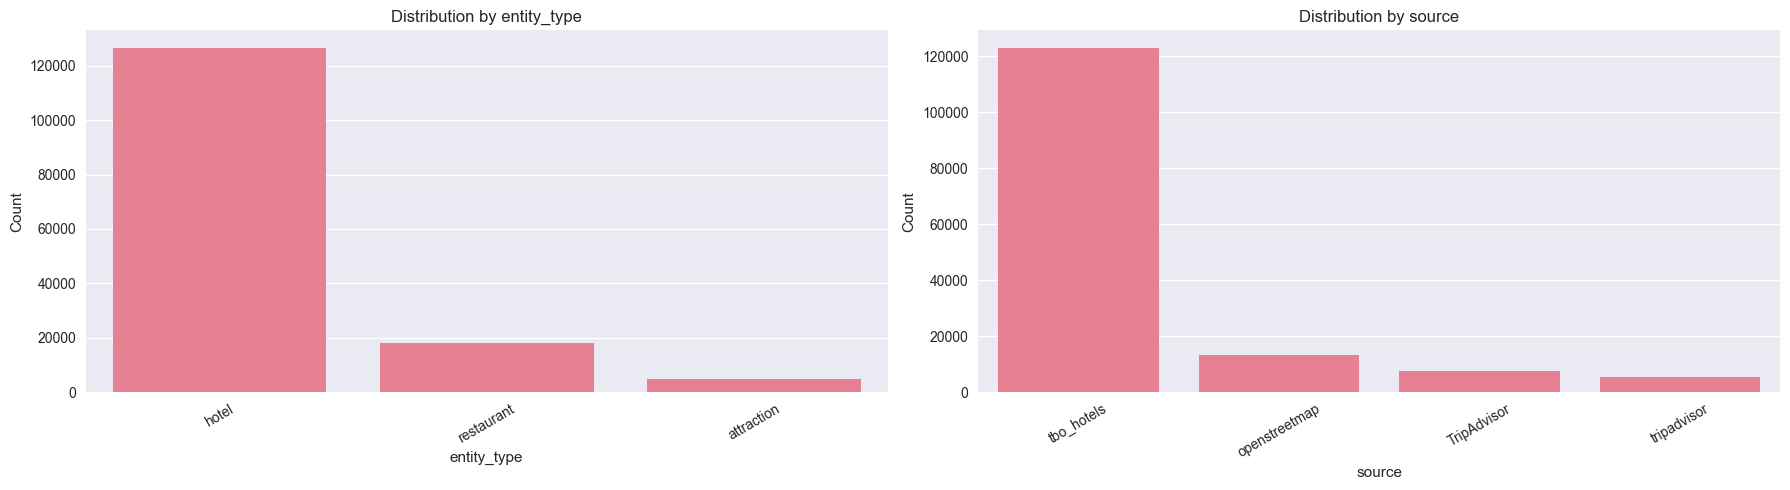

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, col in zip(axes, ["entity_type", "source"]):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f"Distribution by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [18]:
num_cols = ["stars", "review_count", "popularity"]
df[num_cols].describe().round(2)

,stars,review_count,popularity
count,149485.00,149485.00,149485.00
mean,4.15,1563.07,27.47
std,0.60,2462.80,8.88
min,2.70,1.00,1.98
25%,4.07,262.00,23.09
50%,4.44,825.00,29.80
75%,4.54,1901.00,33.78
max,4.93,136601.00,53.56


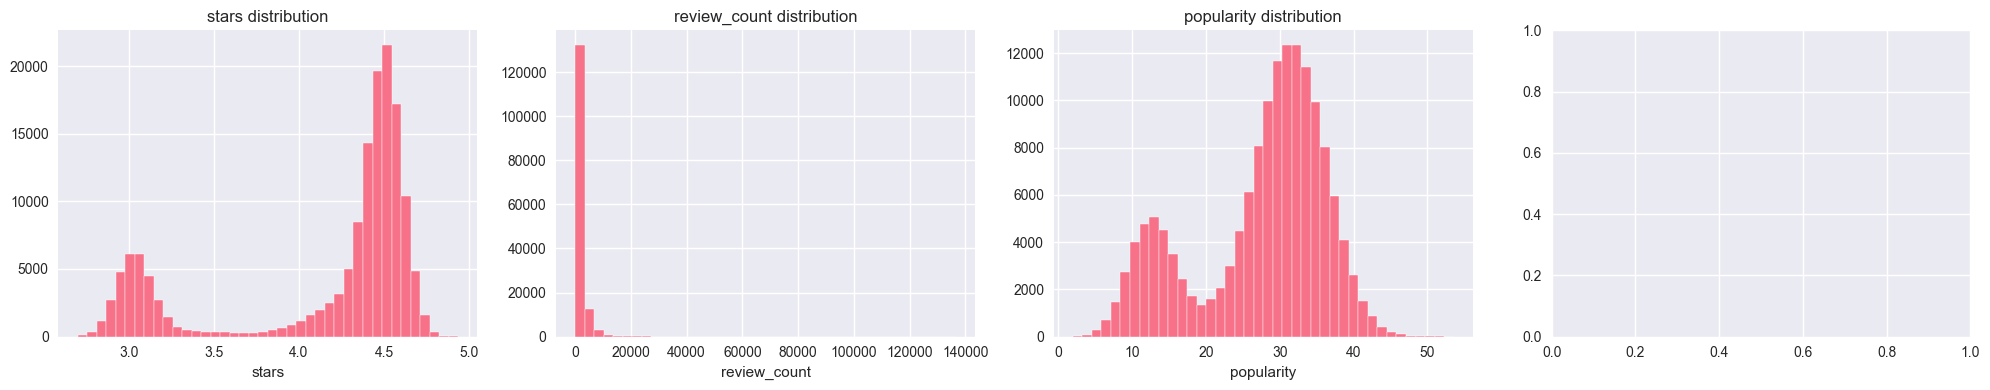

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    df[col].dropna().hist(bins=40, ax=ax, edgecolor="white")
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [20]:
has_coords = df[["latitude", "longitude"]].notnull().all(axis=1)
has_ratings = df["stars"].notnull()

print(f"Rows with coordinates : {has_coords.sum():,} ({has_coords.mean()*100:.1f}%)")
print(f"Rows with star ratings : {has_ratings.sum():,} ({has_ratings.mean()*100:.1f}%)")

Rows with coordinates : 143,835 (96.2%)
Rows with star ratings : 149,485 (100.0%)


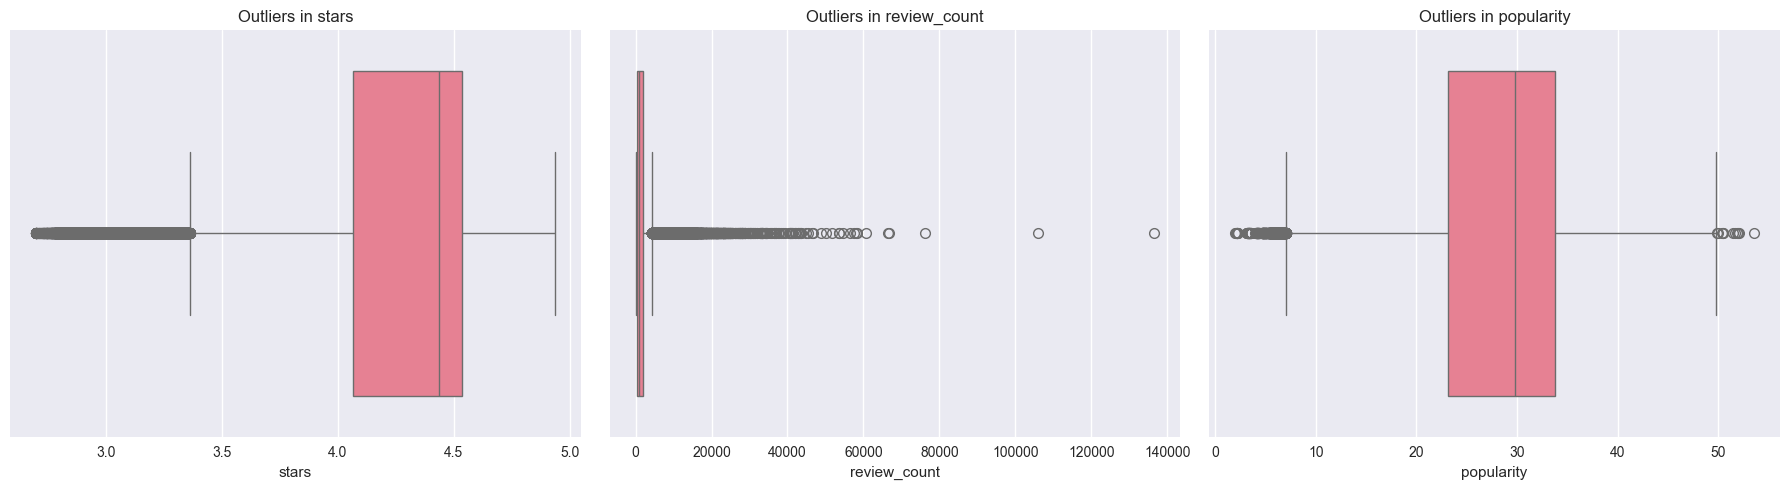

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["stars", "review_count", "popularity"]):
    sns.boxplot(x=df[col].dropna(), ax=ax)
    ax.set_title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

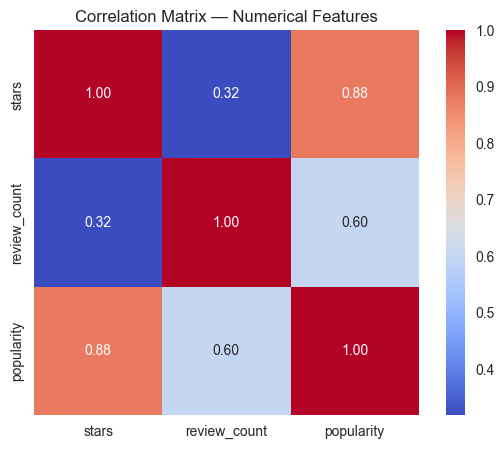

In [22]:
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix — Numerical Features")
plt.show()

In [23]:
print("=== DATASET SUMMARY ===")
print(f"Total records      : {len(df):,}")
print(f"Entity types       : {df['entity_type'].unique()}")
print(f"Sources            : {df['source'].unique()}")
print(f"Countries covered  : {df['country_name'].nunique()}")
print(f"Cities covered     : {df['city'].nunique()}")
print(f"Avg star rating    : {df['stars'].mean():.2f}")
print(f"Median review count: {df['review_count'].median():.0f}")

=== DATASET SUMMARY ===
Total records      : 149,485
Entity types       : <ArrowStringArray>
['restaurant', 'attraction', 'hotel']
Length: 3, dtype: str
Sources            : <ArrowStringArray>
['TripAdvisor', 'openstreetmap', 'tbo_hotels', 'tripadvisor']
Length: 4, dtype: str
Countries covered  : 59
Cities covered     : 61
Avg star rating    : 4.15
Median review count: 825
